# Word2Vec (5/5): Visualización del espacio semántico con retos culturales

En este notebook damos el siguiente paso natural después del preprocesamiento: **entrenar, explorar y visualizar el espacio semántico** construido con Word2Vec sobre el corpus de **retos culturales en Colombia**.

Este cuaderno está pensado para trabajar **directamente con las salidas del Notebook 4**. En particular, intentará cargar:

- `outputs/retos_culturales_preprocesado.csv`
- `outputs/corpus_lemmas.txt`
- `outputs/corpus_tokens.txt`

## Objetivos

Al finalizar podrás:

- entrenar Word2Vec sobre el corpus procesado,
- comparar embeddings basados en **tokens** vs **lemas**,
- proyectar palabras en 2D con **PCA** y **t-SNE**,
- explorar vecinos semánticos,
- construir pequeños grupos temáticos de conceptos,
- generar un **grafo semántico** básico entre términos cercanos,
- y dejar listas algunas ideas para análisis sustantivo del dominio cultural.

> Este notebook no busca solo “entrenar un modelo”, sino **interpretar el espacio semántico** que emerge del corpus.


## 0. Instalación sugerida

Si te hace falta algún paquete, puedes instalarlo así:

```bash
pip install pandas numpy matplotlib gensim scikit-learn networkx
```

Si quieres reutilizar el preprocesamiento con spaCy:

```bash
pip install spacy
python -m spacy download es_core_news_sm
```


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import ast
import itertools
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


## 1. Carga de artefactos del Notebook 4

La idea es aprovechar el trabajo ya hecho de limpieza, deduplicación, tokenización y lematización.

Intentaremos cargar primero el CSV exportado en el Notebook 4. Si existe, podremos recuperar:
- texto limpio,
- tokens,
- lemas,
- y metadatos útiles.

Si no existe, todavía podrías cargar directamente `corpus_tokens.txt` o `corpus_lemmas.txt`.


In [2]:
EXPORT_DIR = Path("outputs")
csv_path = EXPORT_DIR / "retos_culturales_preprocesado.csv"
tokens_txt_path = EXPORT_DIR / "corpus_tokens.txt"
lemmas_txt_path = EXPORT_DIR / "corpus_lemmas.txt"

print("CSV exists:", csv_path.exists())
print("Tokens txt exists:", tokens_txt_path.exists())
print("Lemmas txt exists:", lemmas_txt_path.exists())


CSV exists: True
Tokens txt exists: True
Lemmas txt exists: True


In [3]:
def parse_list_column(value):
    """Safely parse list-like strings coming from CSV export."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text == "":
        return []
    # If the list was stringified as Python list
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return [str(x) for x in parsed]
        except Exception:
            pass
    # Fallback: split by spaces
    return text.split()


def load_corpus_from_txt(path: Path) -> List[List[str]]:
    """Load a corpus from a text file with one pre-tokenized document per line."""
    corpus: List[List[str]] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            doc = line.strip().split()
            if doc:
                corpus.append(doc)
    return corpus


In [4]:
df_processed = None
corpus_tokens: List[List[str]] = []
corpus_lemmas: List[List[str]] = []

if csv_path.exists():
    df_processed = pd.read_csv(csv_path)
    if "tokens" in df_processed.columns:
        df_processed["tokens_list"] = df_processed["tokens"].apply(parse_list_column)
    elif "tokens_str" in df_processed.columns:
        df_processed["tokens_list"] = df_processed["tokens_str"].fillna("").apply(lambda x: str(x).split())
    else:
        df_processed["tokens_list"] = [[] for _ in range(len(df_processed))]

    if "lemmas" in df_processed.columns:
        df_processed["lemmas_list"] = df_processed["lemmas"].apply(parse_list_column)
    elif "lemmas_str" in df_processed.columns:
        df_processed["lemmas_list"] = df_processed["lemmas_str"].fillna("").apply(lambda x: str(x).split())
    else:
        df_processed["lemmas_list"] = [[] for _ in range(len(df_processed))]

    corpus_tokens = [doc for doc in df_processed["tokens_list"].tolist() if doc]
    corpus_lemmas = [doc for doc in df_processed["lemmas_list"].tolist() if doc]

else:
    if tokens_txt_path.exists():
        corpus_tokens = load_corpus_from_txt(tokens_txt_path)
    if lemmas_txt_path.exists():
        corpus_lemmas = load_corpus_from_txt(lemmas_txt_path)

print("Documents in corpus_tokens:", len(corpus_tokens))
print("Documents in corpus_lemmas:", len(corpus_lemmas))


Documents in corpus_tokens: 13267
Documents in corpus_lemmas: 13267


## 2. Elección del corpus para Word2Vec

Aquí puedes elegir si quieres entrenar el modelo con:

- **tokens limpios** (`corpus_tokens`)
- **lemas limpios** (`corpus_lemmas`)

En español, muchas veces los lemas ayudan a consolidar variantes morfológicas.
Por eso empezaremos con `corpus_lemmas` cuando esté disponible.


In [5]:
if len(corpus_lemmas) > 0:
    corpus = corpus_lemmas
    corpus_name = "lemmas"
elif len(corpus_tokens) > 0:
    corpus = corpus_tokens
    corpus_name = "tokens"
else:
    raise ValueError("No processed corpus was found. Run Notebook 4 first or place the exported files inside outputs/.")

print("Selected corpus:", corpus_name)
print("First document:", corpus[0][:30])


Selected corpus: lemmas
First document: ['reto', 'actualizar', 'desarrollo', 'país', 'contexto', 'actual', 'realmente', 'transversal', 'desarrollo', 'social', 'económico', 'político', 'vehículo', 'transformación', 'sociedad', 'post', 'conflicto']


## 3. Diagnóstico básico del corpus

Antes de entrenar Word2Vec, conviene revisar:

- número de documentos,
- longitud promedio,
- vocabulario preliminar,
- palabras más frecuentes.


In [6]:
token_counter = Counter(token for doc in corpus for token in doc)

corpus_summary = pd.DataFrame({
    "metric": [
        "n_documents",
        "avg_doc_length",
        "median_doc_length",
        "vocabulary_size",
        "total_tokens",
    ],
    "value": [
        len(corpus),
        np.mean([len(doc) for doc in corpus]),
        np.median([len(doc) for doc in corpus]),
        len(token_counter),
        sum(token_counter.values()),
    ]
})

corpus_summary


,metric,value
0,n_documents,13267.000000
1,avg_doc_length,18.225597
2,median_doc_length,12.000000
3,vocabulary_size,14528.000000
4,total_tokens,241799.000000


In [7]:
top_words = pd.DataFrame(token_counter.most_common(30), columns=["word", "freq"])
top_words.head(15)


,word,freq
0,reto,4805
1,colombia,2755
2,país,2519
3,artista,2102
4,municipio,2003
5,proceso,1980
6,recurso,1738
7,apoyo,1736
8,artístico,1608
9,sector,1586


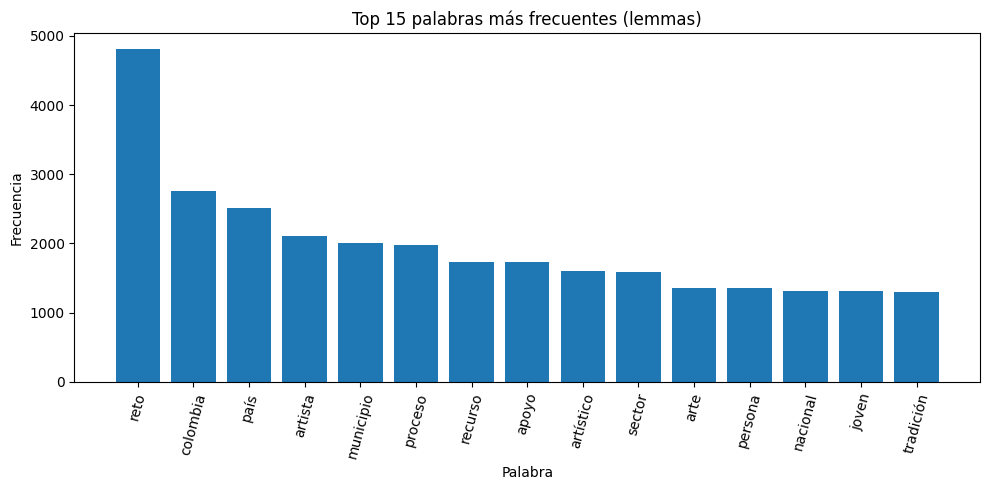

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(top_words.head(15)["word"], top_words.head(15)["freq"])
plt.xticks(rotation=75)
plt.title(f"Top 15 palabras más frecuentes ({corpus_name})")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 4. Entrenamiento de Word2Vec

Vamos a definir una función para entrenar Word2Vec de forma reproducible.

### Hiperparámetros clave

- `vector_size`: dimensión del embedding
- `window`: tamaño de la ventana de contexto
- `min_count`: frecuencia mínima para incluir una palabra
- `sg`:
  - `1` = Skip-gram
  - `0` = CBOW
- `negative`: número de negativos
- `epochs`: número de épocas

En este corpus, empezar con `Skip-gram` y `min_count` entre 2 y 3 suele ser razonable.


In [9]:
def train_word2vec(
    corpus: Sequence[Sequence[str]],
    *,
    vector_size: int = 100,
    window: int = 5,
    min_count: int = 3,
    sg: int = 1,
    negative: int = 10,
    epochs: int = 80,
    seed: int = 7,
) -> Word2Vec:
    return Word2Vec(
        sentences=corpus,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=1,
        sg=sg,
        negative=negative,
        epochs=epochs,
        seed=seed,
    )


model = train_word2vec(
    corpus,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    negative=10,
    epochs=100,
    seed=7,
)

print(model)
print("Vocabulary size in model:", len(model.wv))


Word2Vec<vocab=5616, vector_size=100, alpha=0.025>
Vocabulary size in model: 5616


## 5. Vecinos semánticos

Una de las formas más intuitivas de explorar Word2Vec es ver qué palabras aparecen cerca de otra en el espacio vectorial.

Esto suele ser útil para detectar:
- asociaciones temáticas,
- agrupaciones implícitas,
- conceptos de dominio que tienden a co-ocurrir.


In [10]:
def safe_most_similar(model_wv, word: str, topn: int = 10):
    if word not in model_wv:
        return f"'{word}' is not in the vocabulary."
    return model_wv.most_similar(word, topn=topn)


candidate_terms = [
    "patrimonio",
    "arte",
    "comunidad",
    "territorio",
    "memoria",
    "sabedor",
    "formación",
    "circulación",
    "creación",
    "identidad",
]

for term in candidate_terms:
    print(f"\n=== {term} ===")
    print(safe_most_similar(model.wv, term, topn=8))



=== patrimonio ===
[('inmaterial', 0.7637611627578735), ('patrimonial', 0.5469467639923096), ('identidad', 0.5459432601928711), ('materio', 0.5426835417747498), ('divulgar él', 0.5372233390808105), ('proteger', 0.5303454995155334), ('mueble', 0.5276195406913757), ('paleontológico', 0.5116021037101746)]

=== arte ===
[('artista', 0.5961543321609497), ('art', 0.5713453888893127), ('malabar', 0.5133668184280396), ('profesión', 0.49967196583747864), ('artístico', 0.4927361309528351), ('país', 0.4918694794178009), ('despierto', 0.4800753593444824), ('empíricamente', 0.47890788316726685)]

=== comunidad ===
[('territorio', 0.6417747735977173), ('población', 0.6272570490837097), ('persona', 0.5132721066474915), ('pueblo', 0.5106295943260193), ('aproximación', 0.4862336814403534), ('afrocolombiana', 0.48088955879211426), ('conjunto', 0.4728375971317291), ('palenquera', 0.46856096386909485)]

=== territorio ===
[('comunidad', 0.6417747735977173), ('región', 0.6225661635398865), ('país', 0.5866

## 6. Similaridades dirigidas

También podemos medir la similitud entre pares de términos que nos interesen desde el dominio cultural.

Esto ayuda a responder preguntas como:
- ¿qué tan cerca quedan `patrimonio` y `memoria`?
- ¿qué tan próximos están `territorio` y `comunidad`?
- ¿`formación` se acerca más a `arte` o a `circulación`?


In [11]:
pairs_to_compare = [
    ("patrimonio", "memoria"),
    ("territorio", "comunidad"),
    ("arte", "creación"),
    ("formación", "circulación"),
    ("identidad", "memoria"),
]

for a, b in pairs_to_compare:
    if a in model.wv and b in model.wv:
        sim = model.wv.similarity(a, b)
        print(f"similarity({a}, {b}) = {sim:.4f}")
    else:
        print(f"One of the words is not in the vocabulary: ({a}, {b})")


similarity(patrimonio, memoria) = 0.5094
similarity(territorio, comunidad) = 0.6418
similarity(arte, creación) = 0.2655
similarity(formación, circulación) = 0.4144
similarity(identidad, memoria) = 0.5291


## 7. Analogías exploratorias

En un corpus de dominio como este, no siempre habrá analogías “clásicas” tan limpias como en textos generales.
Aun así, podemos probar relaciones del campo cultural.

Por ejemplo:
- `patrimonio + comunidad - territorio`
- `arte + formación - creación`

La utilidad aquí no es solo “acertar”, sino ver qué estructura semántica emerge.


In [12]:
def safe_analogy(model_wv, positive: Sequence[str], negative: Sequence[str], topn: int = 8):
    missing = [w for w in list(positive) + list(negative) if w not in model_wv]
    if missing:
        return f"Missing words in vocabulary: {missing}"
    return model_wv.most_similar(positive=list(positive), negative=list(negative), topn=topn)


print(safe_analogy(model.wv, positive=["patrimonio", "comunidad"], negative=["territorio"], topn=8))
print()
print(safe_analogy(model.wv, positive=["arte", "formación"], negative=["creación"], topn=8))


[('inmaterial', 0.5527079105377197), ('material', 0.5165369510650635), ('divulgar él', 0.4584778845310211), ('paleontológico', 0.4446486830711365), ('alexandra', 0.4285309910774231), ('flecha', 0.4236404597759247), ('generación', 0.42071112990379333), ('orientir', 0.4071733355522156)]

[('maquillaje', 0.48451799154281616), ('william', 0.47729259729385376), ('música', 0.4704678952693939), ('escuelo', 0.46408870816230774), ('escuela', 0.4579627811908722), ('pintura', 0.45568615198135376), ('proceso', 0.45285534858703613), ('egresado', 0.451243132352829)]


## 8. PCA del espacio semántico

PCA nos permite proyectar los embeddings a 2 dimensiones.
No preserva toda la estructura, pero sí ofrece una primera visualización global.


In [13]:
def plot_embeddings_pca(model_wv, words: Sequence[str], title: str) -> None:
    valid_words = [w for w in words if w in model_wv]
    if len(valid_words) < 2:
        raise ValueError("Need at least two words in vocabulary to plot PCA.")

    X = np.array([model_wv[w] for w in valid_words])

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(9, 7))
    plt.scatter(X_2d[:, 0], X_2d[:, 1])

    for i, word in enumerate(valid_words):
        plt.text(X_2d[i, 0], X_2d[i, 1], word, fontsize=10)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()


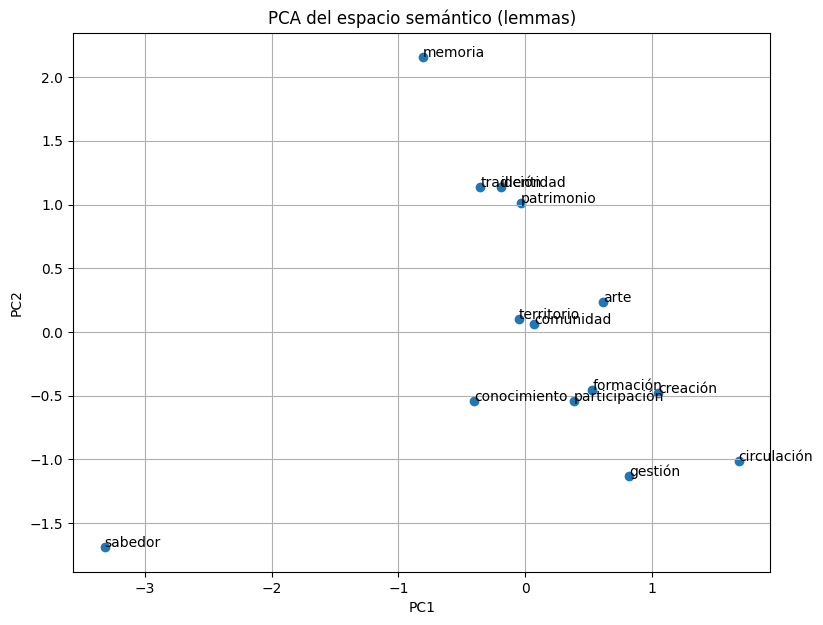

In [14]:
words_to_plot = [
    "patrimonio", "memoria", "identidad", "territorio", "comunidad",
    "arte", "creación", "circulación", "formación", "sabedor",
    "tradición", "participación", "conocimiento", "gestión", "procesos"
]

plot_embeddings_pca(model.wv, words_to_plot, title=f"PCA del espacio semántico ({corpus_name})")


## 9. t-SNE del espacio semántico

Mientras PCA es una proyección lineal, **t-SNE** puede mostrar mejor agrupamientos locales.
Suele ser útil para visualizar cercanías semánticas de forma más intuitiva, aunque es más sensible a hiperparámetros.


In [15]:
def plot_embeddings_tsne(
    model_wv,
    words: Sequence[str],
    *,
    perplexity: int = 5,
    random_state: int = 7,
    title: str = "t-SNE embeddings",
) -> None:
    valid_words = [w for w in words if w in model_wv]
    if len(valid_words) < 3:
        raise ValueError("Need at least three words in vocabulary to plot t-SNE.")

    X = np.array([model_wv[w] for w in valid_words])

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(2, len(valid_words) - 1)),
        random_state=random_state,
        init="pca",
        learning_rate="auto",
    )
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(9, 7))
    plt.scatter(X_2d[:, 0], X_2d[:, 1])

    for i, word in enumerate(valid_words):
        plt.text(X_2d[i, 0], X_2d[i, 1], word, fontsize=10)

    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()


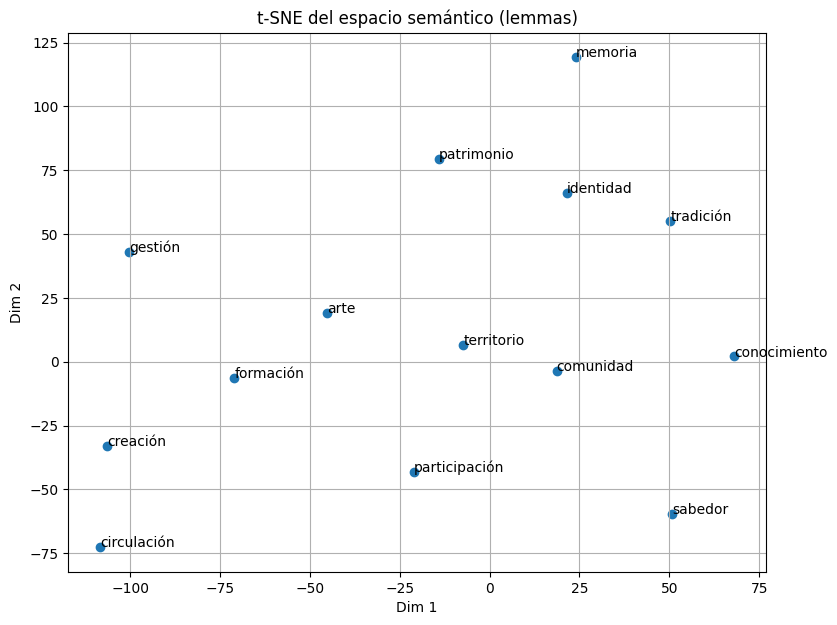

In [16]:
plot_embeddings_tsne(
    model.wv,
    words_to_plot,
    perplexity=5,
    random_state=7,
    title=f"t-SNE del espacio semántico ({corpus_name})",
)


## 10. Clustering de conceptos culturales

Aquí construiremos pequeños grupos sobre un subconjunto de palabras relevantes usando **K-Means**.

Esto no debe interpretarse como una verdad absoluta del dominio, sino como una forma exploratoria de ver si el espacio vectorial organiza conceptos en grupos relativamente coherentes.


In [17]:
def cluster_words(
    model_wv,
    words: Sequence[str],
    *,
    n_clusters: int = 4,
    random_state: int = 7,
) -> pd.DataFrame:
    valid_words = [w for w in words if w in model_wv]
    X = np.array([model_wv[w] for w in valid_words])

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    labels = km.fit_predict(X)

    return pd.DataFrame({
        "word": valid_words,
        "cluster": labels,
    }).sort_values(["cluster", "word"]).reset_index(drop=True)


cluster_df = cluster_words(model.wv, words_to_plot, n_clusters=4, random_state=7)
cluster_df


,word,cluster
0,arte,0
1,comunidad,0
2,conocimiento,0
3,formación,0
4,gestión,0
5,identidad,0
6,participación,0
7,patrimonio,0
8,territorio,0
9,tradición,0


In [18]:
for cluster_id, subdf in cluster_df.groupby("cluster"):
    print(f"\nCluster {cluster_id}")
    print(", ".join(subdf["word"].tolist()))



Cluster 0
arte, comunidad, conocimiento, formación, gestión, identidad, participación, patrimonio, territorio, tradición

Cluster 1
memoria

Cluster 2
circulación, creación

Cluster 3
sabedor


## 11. Grafo semántico básico

Ahora construiremos un **grafo semántico** entre palabras seleccionadas.

### Idea
- cada nodo es una palabra,
- conectamos dos nodos si su similitud coseno es mayor que un umbral.

Esto permite visualizar redes de cercanía temática.


In [19]:
def build_similarity_graph(
    model_wv,
    words: Sequence[str],
    *,
    similarity_threshold: float = 0.35,
) -> nx.Graph:
    valid_words = [w for w in words if w in model_wv]
    G = nx.Graph()
    G.add_nodes_from(valid_words)

    for w1, w2 in itertools.combinations(valid_words, 2):
        sim = model_wv.similarity(w1, w2)
        if sim >= similarity_threshold:
            G.add_edge(w1, w2, weight=float(sim))
    return G


G = build_similarity_graph(model.wv, words_to_plot, similarity_threshold=0.35)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 14
Edges: 23


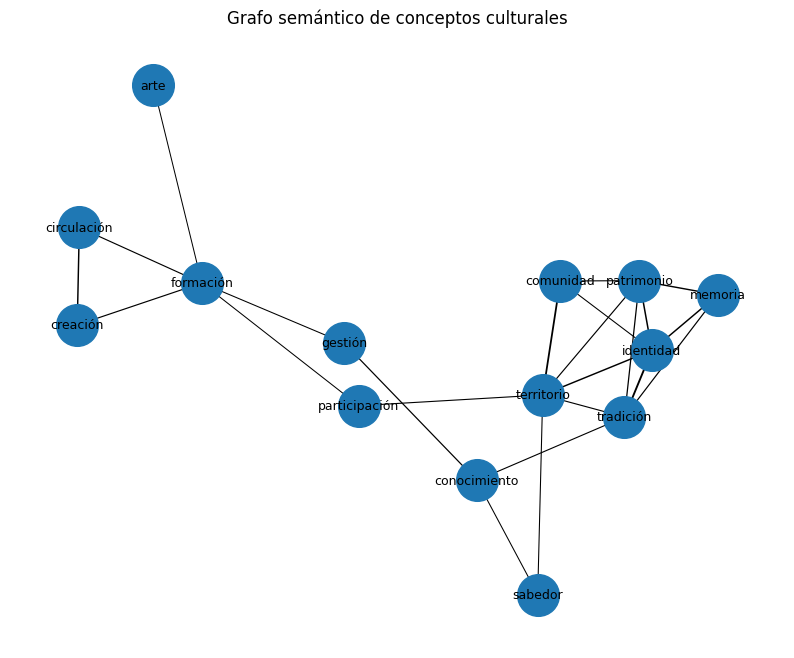

In [20]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=7)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, width=[2 * w for w in edge_weights])

plt.title("Grafo semántico de conceptos culturales")
plt.axis("off")
plt.show()


## 12. Exploración guiada por documento (opcional)

Si el CSV preprocesado está disponible, podemos recuperar algunos documentos donde aparece una palabra de interés y contrastar:

- el comportamiento del embedding,
- con los textos reales que lo produjeron.

Esto es importante porque ayuda a conectar la representación vectorial con la evidencia del corpus.


In [21]:
if df_processed is not None:
    text_col = "text_clean" if "text_clean" in df_processed.columns else None
    lemma_col = "lemmas_str" if "lemmas_str" in df_processed.columns else None

    if lemma_col is not None and text_col is not None:
        target_term = "patrimonio"
        mask = df_processed[lemma_col].fillna("").str.contains(rf"\b{target_term}\b", regex=True)
        examples = df_processed.loc[mask, [text_col, lemma_col]].head(5)
        display(examples)
    else:
        print("The processed CSV is available, but the expected columns were not found.")
else:
    print("No processed CSV found; skipping document-level exploration.")


,text_clean,lemmas_str
49,mejorar las estrategias de mercado en todo el ...,mejorar estrategia mercado sector turismo patr...
61,buscar la manera en la que no permitamos que m...,buscar permitamos conocimiento ancestral perde...
66,el reconocimiento e identificación de las mani...,reconocimiento identificación manifestación pa...
87,apoyar y fomentar la cultura con toda su diver...,apoyar fomentar diversidad bien servicio proye...
97,promoverla y preservarla garantizar el acceso ...,promover él preservar él garantizar acceso seg...


## 13. Comparando modelos: tokens vs lemas

Si tienes disponibles ambos corpus, vale mucho la pena entrenar dos modelos y comparar:

- tamaño del vocabulario,
- vecinos semánticos,
- estabilidad de clusters,
- interpretabilidad.

En español, muchas veces el modelo con lemas reduce ruido; sin embargo, el modelo con tokens puede preservar matices morfológicos interesantes.


In [22]:
comparison_rows = []

if len(corpus_tokens) > 0:
    model_tokens = train_word2vec(corpus_tokens, vector_size=100, window=5, min_count=3, sg=1, negative=10, epochs=80, seed=7)
    comparison_rows.append({
        "corpus": "tokens",
        "documents": len(corpus_tokens),
        "model_vocabulary": len(model_tokens.wv),
    })
else:
    model_tokens = None

if len(corpus_lemmas) > 0:
    model_lemmas = train_word2vec(corpus_lemmas, vector_size=100, window=5, min_count=3, sg=1, negative=10, epochs=80, seed=7)
    comparison_rows.append({
        "corpus": "lemmas",
        "documents": len(corpus_lemmas),
        "model_vocabulary": len(model_lemmas.wv),
    })
else:
    model_lemmas = None

pd.DataFrame(comparison_rows)


,corpus,documents,model_vocabulary
0,tokens,13267,7931
1,lemmas,13267,5616


In [23]:
for term in ["patrimonio", "territorio", "comunidad"]:
    print(f"\n=== {term} ===")
    if model_tokens is not None:
        print("tokens:", safe_most_similar(model_tokens.wv, term, topn=5))
    if model_lemmas is not None:
        print("lemmas:", safe_most_similar(model_lemmas.wv, term, topn=5))



=== patrimonio ===
tokens: [('inmaterial', 0.8289373517036438), ('material', 0.6547325253486633), ('mueble', 0.6060429811477661), ('arquitectónico', 0.5544109344482422), ('arqueológico', 0.5486320853233337)]
lemmas: [('inmaterial', 0.761462926864624), ('materio', 0.5920366048812866), ('divulgar él', 0.5551667809486389), ('patrimonial', 0.5535632371902466), ('identidad', 0.5472507476806641)]

=== territorio ===
tokens: [('salvaguarden', 0.5304206609725952), ('territorios', 0.5206083059310913), ('palenqueros', 0.5106667280197144), ('habitaron', 0.4852125346660614), ('partería', 0.48108160495758057)]
lemmas: [('comunidad', 0.6243312954902649), ('región', 0.620416522026062), ('país', 0.5624831914901733), ('periférico', 0.535858690738678), ('municipio', 0.5222184658050537)]

=== comunidad ===
tokens: [('alexandra', 0.48887312412261963), ('población', 0.4788650572299957), ('célula', 0.46488580107688904), ('llamar', 0.4444710612297058), ('individual', 0.4413532614707947)]
lemmas: [('població

## 14. Guardado del modelo y vectores

Dejamos guardados los artefactos para reutilizarlos después en otros análisis, dashboards o notebooks.


In [24]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / f"word2vec_retos_cultura_{corpus_name}.model"
vec_path = MODEL_DIR / f"word2vec_retos_cultura_{corpus_name}.vec"

model.save(str(model_path))
model.wv.save_word2vec_format(str(vec_path), binary=False)

print("Saved model to:", model_path)
print("Saved vectors to:", vec_path)


Saved model to: models\word2vec_retos_cultura_lemmas.model
Saved vectors to: models\word2vec_retos_cultura_lemmas.vec


## 15. Ideas de interpretación sustantiva

Con este notebook ya puedes empezar a hacer preguntas del dominio, por ejemplo:

- ¿qué palabras quedan cerca de `patrimonio`?
- ¿`territorio` se acerca más a `comunidad`, `memoria` o `identidad`?
- ¿hay un grupo de palabras ligado a **formación**, otro a **circulación**, otro a **memoria**?
- ¿el espacio semántico parece diferenciar enfoques de política cultural, gestión, creación o participación?

Estas preguntas conectan el NLP con la interpretación del problema sustantivo.


## 16. Recomendaciones metodológicas

1. **No sobreinterpretar** un embedding entrenado en un corpus pequeño.  
2. Revisar siempre los **textos reales** que producen las asociaciones.  
3. Comparar varios modelos:
   - tokens vs lemas,
   - CBOW vs Skip-gram,
   - distintos `window` y `min_count`.  
4. Complementar con:
   - frecuencias,
   - n-gramas,
   - clustering de documentos,
   - lectura cualitativa de ejemplos.


## 17. Ejercicios sugeridos

1. Cambia `min_count=2` y compara el vocabulario del modelo.  
2. Entrena un modelo con `sg=0` (CBOW) y compara vecinos semánticos.  
3. Ajusta el umbral del grafo semántico (`similarity_threshold`) y observa cómo cambia la red.  
4. Construye una lista propia de 20 conceptos culturales y revisa sus clusters.  
5. Compara PCA vs t-SNE y analiza qué tipo de estructura muestra cada uno.  
6. (Reto) Construye un análisis por **ejes temáticos**: patrimonio, territorio, creación, formación, memoria, gestión.
